In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from functools import reduce
import time
import pickle


In [2]:
def pauli_str_to_unitary(pstr):
    def char_to_pauli(c):
        if c == "I":
            return np.eye(2)
        elif c == "X":
            return np.array([[0, 1], [1, 0]])
        elif c == "Y":
            return np.array([[0, -1j], [1j, 0]])
        elif c == "Z":
            return np.array([[1, 0], [0, -1]])
        else:
            raise ValueError(f"Invalid Pauli character: {c}")
    
    return reduce(np.kron, [char_to_pauli(c) for c in pstr], np.array([[1]]))

In [3]:
def spin_chain_H(n, J=1, g=1, type="transverse"):
    d = 2**n
    if type == "transverse":
        Hzz, Hx = np.zeros((d, d)), np.zeros((d, d))
        for i in range(n):
            if i < n-1:
                pstr = list("I"*n)
                pstr[i] = pstr[i+1] = "Z"
                Hzz += pauli_str_to_unitary(pstr)
            
            pstr = list("I"*n)
            pstr[i] = "X"
            Hx += pauli_str_to_unitary(pstr)

        Hzz *= -J
        Hx *= -J*g # h = -J*g
        H = Hzz + Hx

    return H, [Hzz, Hx]

In [4]:
def rand_prod_state(n):
    """Random n-qubit product state, implemented without requiring qiskit."""
    def rand_state():
        z = np.random.normal(size=2) + 1j*np.random.normal(size=2)
        return z / np.linalg.norm(z)

    return reduce(np.kron, [rand_state() for _ in range(n)], np.array(1, dtype=complex))


In [5]:
def expect(state, H):
    if state.ndim == 1:
        res = state.conj().T @ H @ state
    else:
        rho = state
        res = np.trace(rho @ H)
    
    assert np.isclose(res.imag, 0)
    return res.real # real-valued observables

def outer(state):
    psi = state.reshape(-1, 1)
    return psi @ psi.conj().T

def trdist(rho, sigma):
    return np.sum(np.abs(np.linalg.svdvals(rho-sigma))) / 2

def spin_cov(rho, spin_ind):
    n = int(np.log2(rho.shape[0]))
    pstr = list('I'*n)
    pstr[spin_ind] = 'X'
    expect_Xi = expect(rho, pauli_str_to_unitary(pstr))
    pstr[spin_ind+1] = 'X'
    expect_XiXiplus1 = expect(rho, pauli_str_to_unitary(pstr))
    pstr[spin_ind] = 'I'
    expect_Xiplus1 = expect(rho, pauli_str_to_unitary(pstr))
    spin_cov = expect_XiXiplus1 - expect_Xi*expect_Xiplus1
    return spin_cov

In [20]:
def _sinc_no_pi(x):
    x = np.asarray(x, dtype=float)
    return np.where(np.isclose(x, 0.0), 1.0, np.sin(x) / x)


def sdelta_pdf(delta):
    if delta <= 0:
        raise ValueError("delta must be positive")

    def pdf(t):
        x = delta * np.asarray(t, dtype=float) / 4.0
        vals = (3.0 * delta) / (8.0 * np.pi) * _sinc_no_pi(x) ** 4
        return float(vals) if np.ndim(t) == 0 else vals

    return pdf


def sample_sdelta(delta, M=1, envelope=6.5):
    if delta <= 0:
        raise ValueError("delta must be positive")
    if M < 1:
        raise ValueError("M must be >= 1")

    # Rejection sampling for S_1 using a standard Cauchy proposal, then scale by 1/delta.
    accepted = []
    while len(accepted) < M:
        batch = max(2 * (M - len(accepted)), 1)
        y = scipy.stats.cauchy.rvs(size=batch)
        u = scipy.stats.uniform.rvs(size=batch)

        target = (3.0 / (8.0 * np.pi)) * _sinc_no_pi(y / 4.0) ** 4
        proposal = 1.0 / (np.pi * (1.0 + y ** 2))
        keep = u < (target / (envelope * proposal))

        if np.any(keep):
            accepted.extend((y[keep] / delta).tolist())

    samples = np.array(accepted[:M])
    return samples if M > 1 else samples[0]

In [6]:
gcauchy_pdf = lambda u: 1/np.pi * 1/(1+(u/np.sqrt(2))**4)

def sample_gcauchy(beta, M=1):
    cs = []
    # pdf = lambda u: 1/np.pi * 1/(1+(u/np.sqrt(2))**4) ~ C_{1/sqrt2}^4
    thresh = (1+np.sqrt(5))/2 # sup u of pdf(u)/cauchypdf(u) = golden ratio
    while len(cs) < M:
        c = scipy.stats.cauchy.rvs()
        u = scipy.stats.uniform.rvs()
        h = (1+c**2)/(1+(c/np.sqrt(2))**4)
        if u < h/thresh:
            cs.append(c)

    return beta*(np.array(cs) if M > 1 else cs[0])

def gcauchy_pdf(beta):
    pdf = lambda u: 1/np.pi * 1/(1+(u/np.sqrt(2))**4)
    return lambda u: 1/beta * pdf(u/beta)

In [7]:
class Hamiltonian:
    def __init__(self, H, Hs=None, steps=0, order=1):
        """
        Dense helper for exact and product-formula imaginary/real-time evolution.

        steps=0 means: treat H as a single block and implement exp(alpha H) exactly.
        Otherwise Hs is the list of product-formula blocks.
        """
        if Hs is None:
            Hs = []
        if steps == 0:
            Hs = [H]
            steps = 1
            order = 1

        self.H = np.asarray(H, dtype=complex)
        self.Hs = [np.asarray(Hi, dtype=complex) for Hi in Hs]
        self.dim = self.H.shape[0]
        self.steps = int(steps)
        self.order = int(order)

        self.Us = []
        self.lams = []
        for Hi in self.Hs:
            eigenvals, eigenvecs = np.linalg.eigh(Hi)
            self.Us.append(eigenvecs)
            self.lams.append(eigenvals)

        eigenvals, eigenvecs = np.linalg.eigh(self.H)
        self.U = eigenvecs
        self.lam = eigenvals
        self.ground = eigenvecs[:, 0]

    # e^{alpha H_i}
    def term(self, i, alpha, method="fast"):
        if "direct" in method:
            return scipy.linalg.expm(self.Hs[i] * alpha)
        if "fast" in method:
            return self.Us[i] @ np.diag(np.exp(self.lams[i] * alpha)) @ self.Us[i].conj().T
        raise ValueError(f"Invalid method: {method}")

    def _formula_step(self, x, order, method="fast"):
        """One product-formula step S_order(x) for exp(x * sum_i H_i)."""
        assert order > 0 and (order == 1 or order % 2 == 0)
        I = np.eye(self.dim, dtype=complex)

        if order == 1:
            terms = [self.term(i, x, method=method) for i in range(len(self.Hs))]
            return reduce(lambda A, B: A @ B, terms, I)

        if order == 2:
            # Strang splitting.  Adjacent half-steps across repeated Trotter steps are
            # not merged here; that only changes constants, not correctness.
            terms = [self.term(i, x / 2, method=method) for i in range(len(self.Hs))]
            forward = reduce(lambda A, B: A @ B, terms, I)
            backward = reduce(lambda A, B: B @ A, terms, I)
            return forward @ backward

        # Correct Suzuki recursion for order 4,6,...
        # S_{2k}(x) = S_{2k-2}(q x)^2 S_{2k-2}((1-4q)x) S_{2k-2}(q x)^2.
        q = 1.0 / (4.0 - 4.0 ** (1.0 / (order - 1)))
        A = self._formula_step(q * x, order - 2, method=method)
        B = self._formula_step((1.0 - 4.0 * q) * x, order - 2, method=method)
        return A @ A @ B @ A @ A

    # e^{alpha H} via a product formula
    def trotter(self, alpha, method="fast", *, steps=None, order=None):
        steps = self.steps if steps is None else int(steps)
        order = self.order if order is None else int(order)
        if steps < 1:
            raise ValueError("steps must be >= 1")
        S = self._formula_step(alpha / steps, order, method=method)
        return np.linalg.matrix_power(S, steps)

    def ITE(self, beta, method="fast", *, steps=None, order=None):
        return self.trotter(-beta, method=method, steps=steps, order=order)

    def RTE(self, t, method="fast", *, steps=None, order=None):
        return self.trotter(-1j * t, method=method, steps=steps, order=order)

    def rte_steps_for_t(self, t, *, beta_ref=None, base_steps=None, order=None,
                        mode="fixed", max_dt=None, min_steps=None):
        """
        Choose the number of RTE Trotter steps for a sampled real time t.

        mode="fixed": use base_steps.
        mode="dt": enforce |t|/T <= max_dt.  This controls per-step size but
            does NOT control global Trotter error by itself.
        mode="error": order-p product-formula error scales like |t|^{p+1}/T^p;
            keeping that roughly constant relative to beta_ref requires
            T(t) ~ base_steps * max(1, |t|/beta_ref)^{1+1/p}.
        """
        base_steps = self.steps if base_steps is None else int(base_steps)
        order = self.order if order is None else int(order)
        min_steps = base_steps if min_steps is None else int(min_steps)

        if mode in (None, False, "fixed"):
            return max(1, base_steps)

        at = abs(float(t))
        if mode == "dt":
            if max_dt is None or max_dt <= 0:
                raise ValueError("max_dt must be positive for mode='dt'")
            return max(min_steps, int(np.ceil(at / max_dt)))

        if mode == "error":
            if beta_ref is None or beta_ref <= 0:
                raise ValueError("beta_ref must be positive for mode='error'")
            scale = max(1.0, at / float(beta_ref))
            return max(min_steps, int(np.ceil(base_steps * scale ** (1.0 + 1.0 / order))))

        raise ValueError(f"Unknown RTE step mode: {mode}")

    def iITE(self, state, beta, method="fast", *, steps=None, order=None):
        psi_ = self.ITE(beta, method=method, steps=steps, order=order) @ state
        return psi_ / np.linalg.norm(psi_)

    def iITE_rand_iRTE(self, state, beta, M=1000, sample=None, pdf=None, method="fast",
                       *, rte_step_mode="fixed", rte_base_steps=None, rte_order=None,
                       max_rte_dt=None, return_meta=False, **kwargs):
        """
        ITE for beta, followed by randomized RTE.

        For finite-Trotter RTE with heavy-tailed t, use rte_step_mode="error".
        Merely enforcing |t|/T < 1 is usually insufficient: order-p global
        error scales as |t|^{p+1}/T^p.
        """
        if sample is None:
            sample = lambda: sample_gcauchy(beta)

        method2 = "direct" if "direct" in method else "fast"
        psi = self.iITE(state, beta, method=method2)
        samples = np.array([sample() for _ in range(M)], dtype=float)

        meta = {"samples": samples, "rte_steps": None}

        if method == "direct":
            states = []
            used_steps = []
            for t in samples:
                st = self.rte_steps_for_t(
                    t, beta_ref=beta, base_steps=rte_base_steps, order=(rte_order or self.order),
                    mode=rte_step_mode, max_dt=max_rte_dt,
                )
                used_steps.append(st)
                states.append(self.RTE(t, method=method2, steps=st, order=(rte_order or self.order)) @ psi)
            rho = sum(outer(s) for s in states) / M
            meta["rte_steps"] = np.array(used_steps, dtype=int)

        elif method == "fast":
            # Exact spectral RTE fast path; this is only valid when Hs=[H].
            assert len(self.Hs) == 1
            c = self.U.conj().T @ psi
            phases = np.exp(-1j * np.outer(self.lam, samples))
            psi_t = self.U @ (c[:, None] * phases)
            rho = psi_t @ psi_t.conj().T / M

        elif method == "integrate":
            if pdf is None:
                pdf = gcauchy_pdf(beta)

            def integrand(t):
                st = self.rte_steps_for_t(
                    t, beta_ref=beta, base_steps=rte_base_steps, order=(rte_order or self.order),
                    mode=rte_step_mode, max_dt=max_rte_dt,
                )
                psi_prime = self.RTE(t, method="fast", steps=st, order=(rte_order or self.order)) @ psi
                return pdf(t) * outer(psi_prime)

            rho = scipy.integrate.quad_vec(integrand, -np.inf, np.inf, **kwargs)[0]

        else:
            raise ValueError(f"Invalid method: {method}")

        if return_meta:
            return rho, meta
        return rho


In [8]:
# hamil = Hamiltonian(spin_chain_H(4)[0])

# psi0 = rand_prod_state(4)
# beta = 1

# # Time each method averaged over 10 runs
# times_integrate = []
# times_direct = []
# times_fast = []

# for _ in range(10):
#     start = time.time()
#     rho = hamil.iITE_rand_iRTE(psi0, beta, M=int(1e3), pdf=gcauchy_pdf(beta), method="integrate", epsrel=1e-4)
#     times_integrate.append(time.time() - start)
        
#     start = time.time()
#     rho_2 = hamil.iITE_rand_iRTE(psi0, beta, M=int(1e3), sample=lambda: sample_gcauchy(beta), method="direct") 
#     times_direct.append(time.time() - start)
    
#     start = time.time()
#     rho_3 = hamil.iITE_rand_iRTE(psi0, beta, M=int(1e3), sample=lambda: sample_gcauchy(beta), method="fast")
#     times_fast.append(time.time() - start)

# print(f"Average times:")
# print(f"Integrate: {np.mean(times_integrate):.3f}s")
# print(f"Direct: {np.mean(times_direct):.3f}s") 
# print(f"Fast: {np.mean(times_fast):.3f}s")


In [9]:
# Removed stale debug cell: `len(hamil.Hs)` before `hamil` exists.


In [10]:
n = 4
g = 1.4
J = 1.0
omega = 1.0
excited_ind = 0
H, Hs = spin_chain_H(n, J=J, g=g)
T = 1

psi0s = [rand_prod_state(n) for _ in range(T)]
memory = {}

In [22]:
# Dense ideal simulation: compare ITE, hybrid RTE with fixed RTE steps,
# and hybrid RTE with adaptive RTE steps.
#
# Important fix: enforcing |t|/T < 1 only controls the per-step time.
# For an order-p product formula, the global RTE Trotter error scales like
# |t|^{p+1}/T^p, so keeping the error roughly fixed requires
# T(t) ~ T0 * max(1, |t|/beta)^{1+1/p}.

n = 4
g = 1.4
J = 1.0
excited_ind = 0
H, Hs = spin_chain_H(n, J=J, g=g)

T = 1
psi0s = [rand_prod_state(n) for _ in range(T)]
memory = {}

steps, order = 10, 2
hamil = Hamiltonian(H, Hs, steps=steps, order=order)
Delta = hamil.lam[1] - hamil.lam[0]
spin_ind = min(2, n-2)

# Keep this moderate for interactive debugging.  Increase M after the curves look sane.
betas = np.linspace(0.05, 10.0, 16)
M_rte = int(5e2)

data = {'rhos': dict(), 'energies': dict(), 'spincov': dict(), 'trd': dict()}

method_names = ['iITE', 'rITE_fixed_RTE_T', 'rITE_adaptive_RTE_T']
methods = [
    lambda psi0, beta: outer(hamil.iITE(psi0, beta, method="direct")),
    lambda psi0, beta: hamil.iITE_rand_iRTE(
        psi0, beta, M=M_rte,
        sample=lambda beta=beta: sample_sdelta(Delta),
        method="direct",
        rte_step_mode="fixed",
    ),
    lambda psi0, beta: hamil.iITE_rand_iRTE(
        psi0, beta, M=M_rte,
        sample=lambda beta=beta: sample_sdelta(Delta),
        method="direct",
        rte_step_mode="error",          # <-- the important fix
        rte_base_steps=steps,
        rte_order=order,
    ),
]

for mi, method in enumerate(methods):
    mn = method_names[mi]
    print(f"Method: {mn}")

    for psi0 in psi0s:
        d = {k: [] for k in data}
        for beta in betas:
            print(f"  beta: {beta:.3f}")
            rho = method(psi0, beta)
            d['rhos'].append(rho)
            d['energies'].append(expect(rho, H))
            d['trd'].append(trdist(rho, outer(hamil.ground)))
            d['spincov'].append(spin_cov(rho, spin_ind))

        for k in data:
            data[k].setdefault(mn, [])
            data[k][mn].append(d[k])

for k in data:
    for mn in data[k]:
        data[k][mn] = np.array(data[k][mn])

memory[(steps, order, 'fixed_vs_adaptive_rte')] = data


Method: iITE
  beta: 0.050
  beta: 0.713
  beta: 1.377
  beta: 2.040
  beta: 2.703
  beta: 3.367
  beta: 4.030
  beta: 4.693
  beta: 5.357
  beta: 6.020
  beta: 6.683
  beta: 7.347
  beta: 8.010
  beta: 8.673
  beta: 9.337
  beta: 10.000
Method: rITE_fixed_RTE_T
  beta: 0.050
  beta: 0.713
  beta: 1.377
  beta: 2.040
  beta: 2.703
  beta: 3.367
  beta: 4.030
  beta: 4.693
  beta: 5.357
  beta: 6.020
  beta: 6.683
  beta: 7.347
  beta: 8.010
  beta: 8.673
  beta: 9.337
  beta: 10.000
Method: rITE_adaptive_RTE_T
  beta: 0.050
  beta: 0.713
  beta: 1.377
  beta: 2.040
  beta: 2.703
  beta: 3.367
  beta: 4.030
  beta: 4.693
  beta: 5.357
  beta: 6.020
  beta: 6.683
  beta: 7.347
  beta: 8.010
  beta: 8.673
  beta: 9.337
  beta: 10.000


In [23]:
import pickle

filename = f"data_n{n}_g{g}_J{J}_exact.pkl"
with open(filename, "wb") as f:
    pickle.dump(data, f)

Slope for iITE: 0.088
Slope for rITE_fixed_RTE_T: 0.039
Slope for rITE_adaptive_RTE_T: 0.116


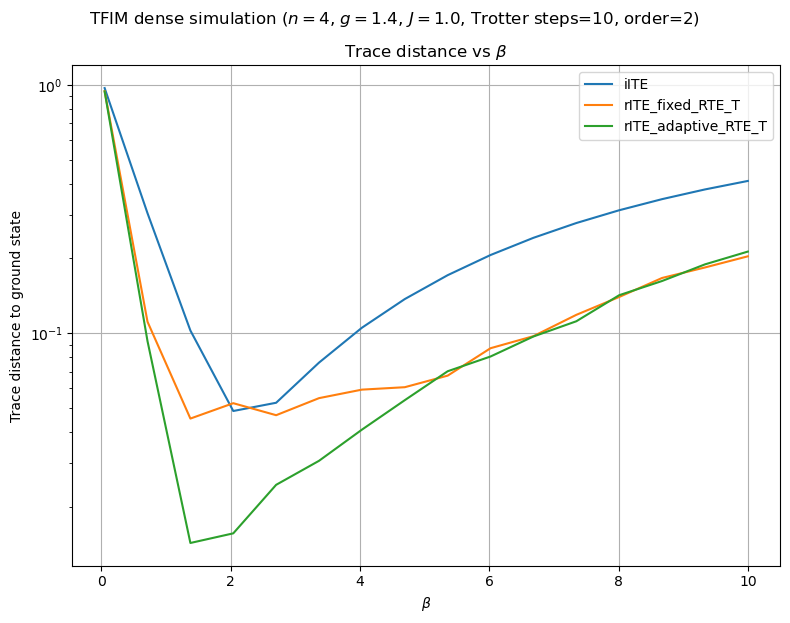

In [24]:
def energy_plot(ax, data, method_names, betas):
    for method in method_names:
        ax.plot(betas, np.mean(data['energies'][method], axis=0), label=method)
    ax.set_xlabel(r'$\beta$')
    ax.set_ylabel(r'Energy $\mathrm{Tr}(\rho H)$')
    ax.set_title(r'Energy vs $\beta$')
    ax.legend()
    ax.grid(True)

def trd_plot(ax, data, method_names, betas, suffix="", linestyle='-'):
    for method in method_names:
        y_data = np.mean(data['trd'][method], axis=0)
        ax.plot(betas, y_data, linestyle, label=(method + " " + suffix).strip())
        mask = np.isfinite(y_data) & (y_data > 0)
        if np.count_nonzero(mask) >= 2:
            params, _ = scipy.optimize.curve_fit(lambda x, m, b: m*x + b, betas[mask], np.log(y_data[mask]))
            print(f"Slope for {method}: {params[0]:.3f}")
    ax.set_xlabel(r'$\beta$')
    ax.set_ylabel(r'Trace distance to ground state')
    ax.set_title(r'Trace distance vs $\beta$')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True)

def spincov_plot(ax, data, method_names, betas):
    for method in method_names:
        ax.plot(betas, np.mean(data['spincov'][method], axis=0), label=f'{method} at i = {spin_ind}')
    ax.set_xlabel(r'$\beta$')
    ax.set_ylabel(r'Spin covariance')
    ax.set_title(r'Spin covariance vs $\beta$')
    ax.legend()
    ax.grid(True)

def spincov_rel_err_plot(ax, data, method_names, betas):
    ref = np.mean(data['spincov']['iITE'], axis=0)
    for method in method_names:
        if method == 'iITE':
            continue
        val = np.mean(data['spincov'][method], axis=0)
        rel_err = np.abs(val - ref) / np.maximum(np.abs(ref), 1e-15)
        ax.plot(betas, rel_err, label=f'{method} relative error at i = {spin_ind}')
    ax.set_xlabel(r'$\beta$')
    ax.set_ylabel('Relative error')
    ax.set_title('Relative error in spin covariance')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
trd_plot(ax, data, method_names, betas)
plt.tight_layout()
plt.suptitle(rf'TFIM dense simulation ($n={n}$, $g={g}$, $J={J}$, Trotter steps={steps}, order={order})', y=1.03)
plt.show()


In [14]:
# Small sanity check from old notebook retained as comment.
# np.log10(100)


In [15]:
# Optional: load previously saved data files, if they exist.
# This cell is intentionally guarded so the notebook runs from a fresh checkout.
from pathlib import Path

g_values = [1.01, 1.3, 1.5, 1.7]
data_list = []
for g_load in g_values:
    fn = Path(f'data_n{n}_g{g_load}_spin{spin_ind}_T{T}.pkl')
    if fn.exists():
        with open(fn, 'rb') as f:
            data_list.append((g_load, pickle.load(f)))

if data_list:
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (g_load, data_load) in enumerate(data_list):
        for method in method_names:
            if method not in data_load['trd']:
                continue
            linestyle = '-' if method == 'iITE' else '--'
            ax.plot(
                betas,
                np.mean(data_load['trd'][method], axis=0),
                linestyle,
                color=f'C{i}',
                label=f'{method} (g = {g_load})',
            )
    ax.set_xlabel(r'$\beta$')
    ax.set_ylabel('Trace distance')
    ax.set_title(rf'Trace distance vs $\beta$ for saved data files ($n={n}$)')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print('No saved comparison files found; skipping optional comparison plot.')


No saved comparison files found; skipping optional comparison plot.


fixed steps: 10
adaptive steps: min/median/mean/max = 10 10.0 16.0698 323
max |t|/T fixed: 1.0141451188250759
max |t|/T adaptive: 0.09992612250563945


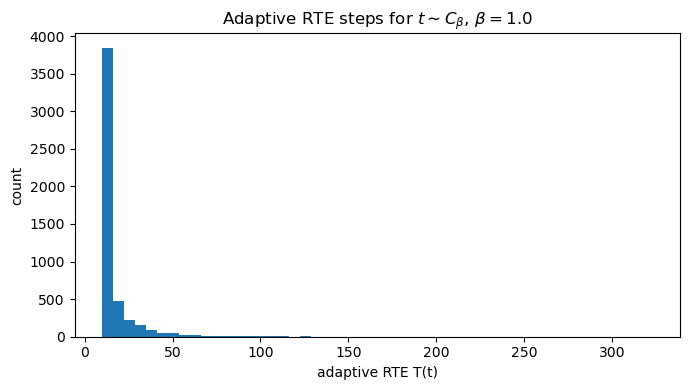

In [16]:
# Diagnostic: inspect the adaptive RTE step rule for the sampled times.
beta_test = 1.0
samples_test = sample_gcauchy(beta_test, M=5000)
steps_fixed = np.full_like(samples_test, steps, dtype=int)
steps_adapt = np.array([
    hamil.rte_steps_for_t(t, beta_ref=beta_test, base_steps=steps, order=order, mode="error")
    for t in samples_test
])

print("fixed steps:", steps_fixed[0])
print("adaptive steps: min/median/mean/max =", np.min(steps_adapt), np.median(steps_adapt), np.mean(steps_adapt), np.max(steps_adapt))
print("max |t|/T fixed:", np.max(np.abs(samples_test) / steps_fixed))
print("max |t|/T adaptive:", np.max(np.abs(samples_test) / steps_adapt))

plt.figure(figsize=(7, 4))
plt.hist(steps_adapt, bins=50)
plt.xlabel("adaptive RTE T(t)")
plt.ylabel("count")
plt.title(rf"Adaptive RTE steps for $t\sim C_\beta$, $\beta={beta_test}$")
plt.tight_layout()
plt.show()
